# Transfer Learning USAD → Detección de Anomalías de Temperatura SIATA

Adapta el modelo USAD pre-entrenado en el dataset SWaT (51 sensores industriales) para detectar
anomalías de temperatura en las 4 estaciones meteorológicas SIATA del Valle de Aburrá, Medellín.

**Estrategia de transfer learning:** Inicialización por submatriz — se copian las submatrices
superiores-izquierdas de los pesos pre-entrenados como punto de partida para la nueva arquitectura
de menor dimensión.

**Referencia:** Audibert et al. (2020). USAD: UnSupervised Anomaly Detection on multivariate time series. KDD 2020.

## Sección 0 — Setup

### Si estás en Google Colab, monta tu Drive primero:
```python
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/monografia/modelos/usad')  # ajustar ruta
```

In [1]:
# ─── SETUP GOOGLE COLAB ─────────────────────────────────────────────────────
# Ejecuta esta celda primero si estás en Google Colab.
# Requiere un secret llamado GITHUB_TOKEN:
#   Panel izquierdo > ícono 🔑 Secrets > Add new secret
#   Name: GITHUB_TOKEN  |  Value: tu Personal Access Token de GitHub
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import userdata
    TOKEN    = userdata.get('GITHUB_TOKEN')
    USER     = 'ronvas234'
    REPO     = 'data-science-monograph'
    WORKDIR  = f'/content/{REPO}/modelos/usad'
    REPO_URL = f'https://{TOKEN}@github.com/{USER}/{REPO}.git'

    if not os.path.exists(f'/content/{REPO}/.git'):
        os.system(f'git clone --quiet {REPO_URL} /content/{REPO}')
        print('Repo clonado.')
    else:
        os.system(f'git -C /content/{REPO} pull --quiet')
        print('Repo actualizado.')

    os.chdir(WORKDIR)
    print(f'Directorio: {os.getcwd()}')
    print('Archivos:', os.listdir('.'))


Repo clonado.
Directorio: /content/data-science-monograph/modelos/usad
Archivos: ['USAD.ipynb', 'Transfer_Learning_SIATA.ipynb', 'PLAN.md', 'usad.py', 'data_new', 'README.md', 'LICENSE', 'utils.py', 'gdrivedl.py', 'model.pth']


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.utils.data as data_utils
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report

from utils import *
from usad import *

device = get_default_device()
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## Sección 1 — Análisis Exploratorio de Datos (EDA)

In [3]:
# Cargar datos
df = pd.read_csv('data_new/temperatura_estaciones_marzo_abril_2025.csv',
                 parse_dates=['fecha_hora'])
print(f'Total filas: {len(df):,}')
print(f'Estaciones: {df["estacion_nombre"].unique()}')
print(f'Periodo: {df["fecha_hora"].min()} → {df["fecha_hora"].max()}')
print(f'\nValores calidad_dudosa=True: {df["calidad_dudosa"].sum():,} ({df["calidad_dudosa"].mean()*100:.2f}%)')
df.head()

Total filas: 350,308
Estaciones: ['Jardin Botanico' 'Torre SIATA' 'UNAN' 'Fiscalia General']
Periodo: 2025-03-01 00:00:00 → 2025-04-30 23:59:00

Valores calidad_dudosa=True: 12,166 (3.47%)


,codigo,estacion_nombre,fecha_hora,t,calidad,calidad_dudosa
0,68,Jardin Botanico,2025-03-01 00:00:00,19.50,1,False
1,201,Torre SIATA,2025-03-01 00:00:00,19.30,1,False
2,203,UNAN,2025-03-01 00:00:00,19.10,1,False
3,478,Fiscalia General,2025-03-01 00:00:00,19.97,1,False
4,68,Jardin Botanico,2025-03-01 00:01:00,19.50,1,False


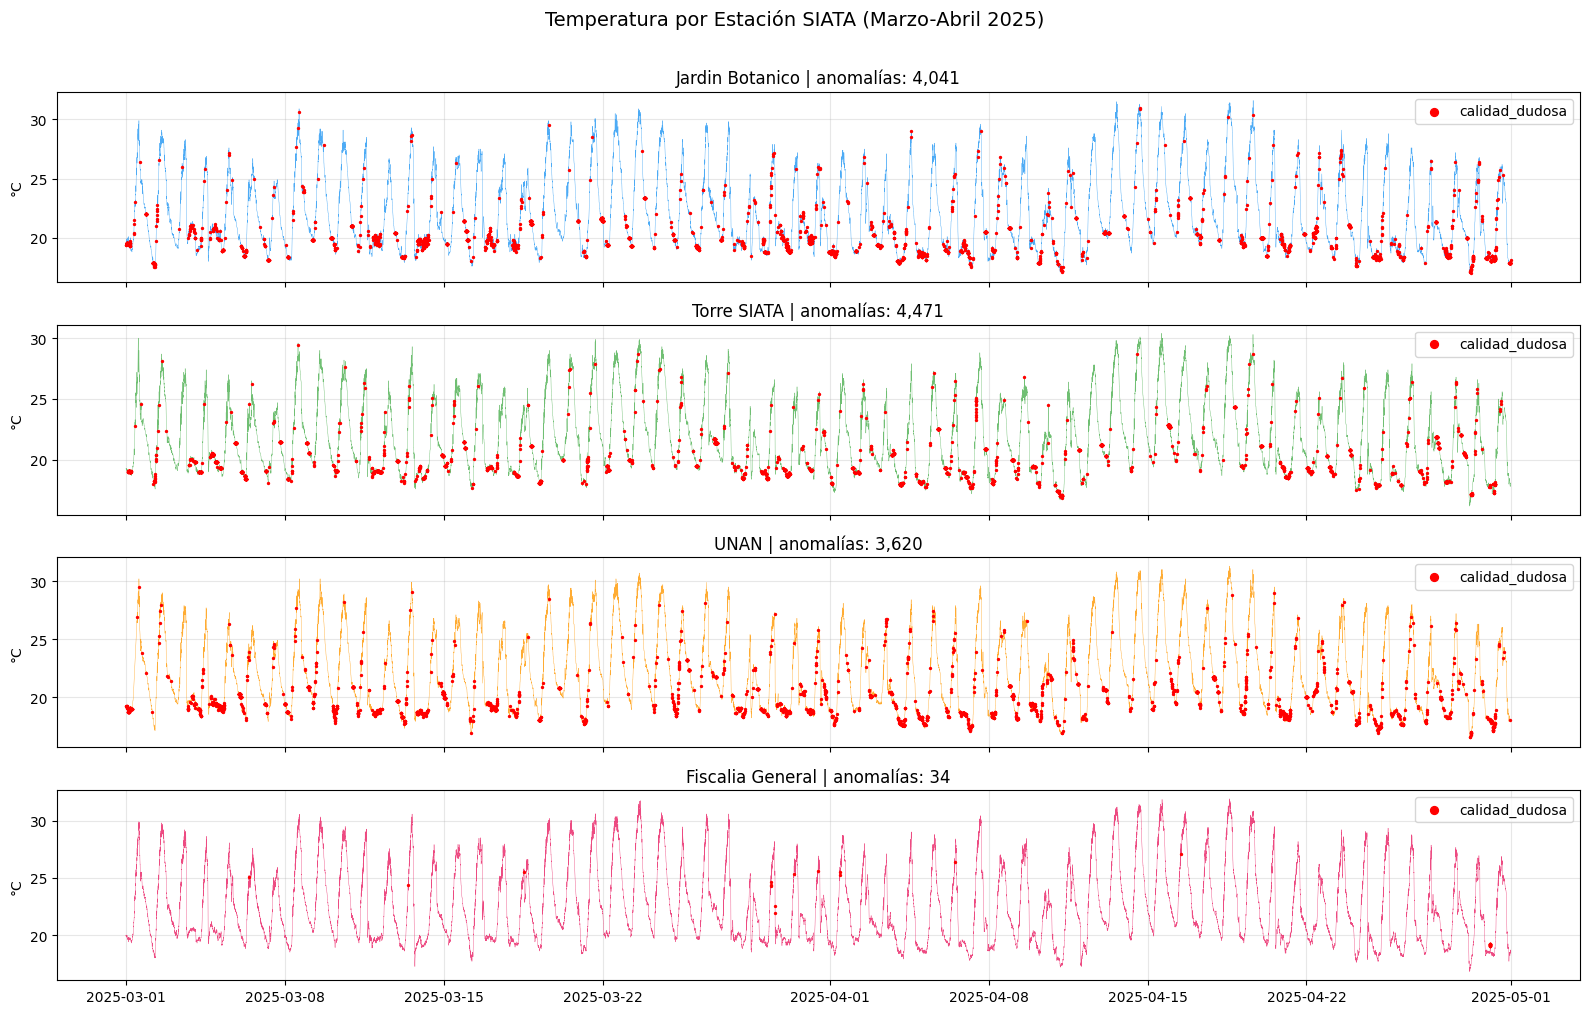

In [4]:
# Temperatura por estación
fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
stations = df['estacion_nombre'].unique()
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
for ax, station, color in zip(axes, stations, colors):
    sub = df[df['estacion_nombre'] == station]
    ax.plot(sub['fecha_hora'], sub['t'], linewidth=0.3, color=color, alpha=0.8)
    # Marcar puntos anómalos
    anomalies = sub[sub['calidad_dudosa'] == True]
    ax.scatter(anomalies['fecha_hora'], anomalies['t'], color='red', s=2, zorder=5, label='calidad_dudosa')
    ax.set_ylabel('°C')
    ax.set_title(f'{station} | anomalías: {len(anomalies):,}')
    ax.legend(loc='upper right', markerscale=4)
    ax.grid(True, alpha=0.3)
plt.suptitle('Temperatura por Estación SIATA (Marzo-Abril 2025)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# Estadísticas por estación
stats = df.groupby('estacion_nombre').agg(
    t_min=('t', 'min'),
    t_mean=('t', 'mean'),
    t_max=('t', 'max'),
    t_std=('t', 'std'),
    n_anomalias=('calidad_dudosa', 'sum'),
    pct_anomalias=('calidad_dudosa', 'mean')
)
stats['pct_anomalias'] = (stats['pct_anomalias'] * 100).round(2)
print(stats.to_string())

                  t_min     t_mean  t_max     t_std  n_anomalias  pct_anomalias
estacion_nombre                                                                
Fiscalia General   16.8  22.521447   31.9  3.290279           34           0.04
Jardin Botanico    17.0  22.024014   31.6  3.197740         4041           4.64
Torre SIATA        16.2  21.714102   30.4  2.966445         4471           5.09
UNAN               16.4  21.889759   31.3  3.258770         3620           4.13


## Sección 2 — Preprocesamiento de Datos

In [6]:
# Extraer labels antes de pivotar
labels_long = df[['fecha_hora', 'calidad_dudosa']].copy()

# Pivot: formato largo → ancho (4 columnas de temperatura por estación)
df_wide = df.pivot(index='fecha_hora', columns='codigo', values='t').sort_index()
df_wide.columns = [f'station_{c}' for c in df_wide.columns]

# Imputar NaN: forward fill luego backward fill (gaps por estación sin lectura)
nan_antes = df_wide.isnull().sum().sum()
df_wide = df_wide.ffill().bfill()
nan_despues = df_wide.isnull().sum().sum()
print(f'Forma: {df_wide.shape}')
print(f'NaN antes de imputar: {nan_antes}, después: {nan_despues}')
df_wide.head(3)


Forma: (87840, 4)
NaN antes de imputar: 1052, después: 0


,station_68,station_201,station_203,station_478
fecha_hora,,,,
2025-03-01 00:00:00,19.5,19.3,19.1,19.97
2025-03-01 00:01:00,19.5,19.3,19.1,20.00
2025-03-01 00:02:00,19.5,19.3,19.1,19.99


In [7]:
# Label por timestamp: True si CUALQUIER estación tiene calidad dudosa
labels_per_ts = labels_long.groupby('fecha_hora')['calidad_dudosa'].any().astype(int)
labels_per_ts = labels_per_ts.reindex(df_wide.index, fill_value=0)
print(f'Timestamps anómalos: {labels_per_ts.sum():,} / {len(labels_per_ts):,} ({labels_per_ts.mean()*100:.2f}%)')

Timestamps anómalos: 10,960 / 87,840 (12.48%)


In [8]:
# Normalización MinMaxScaler, fit SOLO sobre datos normales (igual que SWaT original)
normal_mask = (labels_per_ts.values == 0)
scaler = MinMaxScaler()
scaler.fit(df_wide.values[normal_mask])
df_scaled = scaler.transform(df_wide.values)
print(f'Rango después de normalizar: [{df_scaled.min():.3f}, {df_scaled.max():.3f}]')

Rango después de normalizar: [0.000, 1.000]


In [9]:
# Sliding windows
window_size = 60  # 1 hora de contexto a resolución 1-minuto
data = df_scaled
labels_arr = labels_per_ts.values
N = len(data)

# Crear ventanas deslizantes
windows = data[np.arange(window_size)[None, :] + np.arange(N - window_size)[:, None]]
windows = windows.reshape(len(windows), -1)  # (N-ws, window_size*4) = (N-ws, 240)
print(f'Ventanas creadas: {windows.shape}')  # ~(87517, 240)

# Labels por ventana: mayoría simple (>30 de 60 timesteps anómalos)
window_labels = np.array([
    1 if np.sum(labels_arr[i:i + window_size]) > window_size // 2 else 0
    for i in range(N - window_size)
])
print(f'Ventanas anómalas: {window_labels.sum():,} ({window_labels.mean()*100:.2f}%)')
print(f'Ventanas normales: {(1-window_labels).sum():,}')

Ventanas creadas: (87780, 240)
Ventanas anómalas: 7,923 (9.03%)
Ventanas normales: 79,857


In [10]:
# Split entrenamiento/validación: SOLO ventanas 100% limpias (sin ningún timestep anómalo)
clean_mask = np.array([
    np.sum(labels_arr[i:i + window_size]) == 0
    for i in range(N - window_size)
])
clean_windows = windows[clean_mask]
split = int(0.8 * len(clean_windows))
windows_train = clean_windows[:split]
windows_val   = clean_windows[split:]
windows_test  = windows
y_test        = window_labels

print(f'Train: {len(windows_train):,} ventanas limpias')
print(f'Val:   {len(windows_val):,} ventanas limpias')
print(f'Test:  {len(windows_test):,} ventanas (normal + anómalas)')

Train: 24,514 ventanas limpias
Val:   6,129 ventanas limpias
Test:  87,780 ventanas (normal + anómalas)


In [11]:
# Hiperparámetros
w_size     = window_size * 4  # 240  (60 min × 4 estaciones)
z_size     = 120              # coincide con model.pth pre-entrenado
BATCH_SIZE = 512

train_loader = data_utils.DataLoader(
    data_utils.TensorDataset(torch.from_numpy(windows_train).float()),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

val_loader = data_utils.DataLoader(
    data_utils.TensorDataset(torch.from_numpy(windows_val).float()),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

test_loader = data_utils.DataLoader(
    data_utils.TensorDataset(torch.from_numpy(windows_test).float()),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'w_size={w_size}, z_size={z_size}')
print(f'Batches por epoch (train): {len(train_loader)}')


w_size=240, z_size=120
Batches por epoch (train): 48


## Sección 3 — Inspección del Modelo Pre-Entrenado y Transfer Learning

In [12]:
# Inspeccionar dimensiones del modelo pre-entrenado
ckpt = torch.load('model.pth', map_location='cpu')
print('=== Modelo pre-entrenado ===')
for component in ['encoder', 'decoder1']:
    print(f'\n{component}:')
    for key, val in ckpt[component].items():
        print(f'  {key}: {tuple(val.shape)}')


=== Modelo pre-entrenado ===

encoder:
  linear1.weight: (306, 612)
  linear1.bias: (306,)
  linear2.weight: (153, 306)
  linear2.bias: (153,)
  linear3.weight: (120, 153)
  linear3.bias: (120,)

decoder1:
  linear1.weight: (153, 120)
  linear1.bias: (153,)
  linear2.weight: (306, 153)
  linear2.bias: (306,)
  linear3.weight: (612, 306)
  linear3.bias: (612,)


In [13]:
# Dimensiones del nuevo modelo (SIATA: w_size=240, z_size=1200)
model_transfer = UsadModel(w_size, z_size)
print(f'=== Nuevo modelo (SIATA: w_size={w_size}, z_size={z_size}) ===')
for name, param in model_transfer.named_parameters():
    print(f'  {name}: {tuple(param.shape)}')
total_params = sum(p.numel() for p in model_transfer.parameters())
print(f'\nTotal parámetros: {total_params:,}')

=== Nuevo modelo (SIATA: w_size=240, z_size=120) ===
  encoder.linear1.weight: (120, 240)
  encoder.linear1.bias: (120,)
  encoder.linear2.weight: (60, 120)
  encoder.linear2.bias: (60,)
  encoder.linear3.weight: (120, 60)
  encoder.linear3.bias: (120,)
  decoder1.linear1.weight: (60, 120)
  decoder1.linear1.bias: (60,)
  decoder1.linear2.weight: (120, 60)
  decoder1.linear2.bias: (120,)
  decoder1.linear3.weight: (240, 120)
  decoder1.linear3.bias: (240,)
  decoder2.linear1.weight: (60, 120)
  decoder2.linear1.bias: (60,)
  decoder2.linear2.weight: (120, 60)
  decoder2.linear2.bias: (120,)
  decoder2.linear3.weight: (240, 120)
  decoder2.linear3.bias: (240,)

Total parámetros: 130,740


In [14]:
# Verificar que todas las dimensiones nuevas son <= a las pre-entrenadas
print('Verificación de compatibilidad de dimensiones:')
print(f'{"Capa":<30} {"Pre-entrenado":<20} {"Nuevo":<20} {"Compatible"}')
print('-' * 80)
new_state = dict(model_transfer.named_parameters())
for component in ['encoder', 'decoder1']:
    for key, src in ckpt[component].items():
        full_key = f'{component}.{key}'
        if full_key in new_state:
            dst = new_state[full_key]
            compatible = all(s >= d for s, d in zip(src.shape, dst.shape))
            print(f'{full_key:<30} {str(tuple(src.shape)):<20} {str(tuple(dst.shape)):<20} {"✓" if compatible else "✗"}')

Verificación de compatibilidad de dimensiones:
Capa                           Pre-entrenado        Nuevo                Compatible
--------------------------------------------------------------------------------
encoder.linear1.weight         (306, 612)           (120, 240)           ✓
encoder.linear1.bias           (306,)               (120,)               ✓
encoder.linear2.weight         (153, 306)           (60, 120)            ✓
encoder.linear2.bias           (153,)               (60,)                ✓
encoder.linear3.weight         (120, 153)           (120, 60)            ✓
encoder.linear3.bias           (120,)               (120,)               ✓
decoder1.linear1.weight        (153, 120)           (60, 120)            ✓
decoder1.linear1.bias          (153,)               (60,)                ✓
decoder1.linear2.weight        (306, 153)           (120, 60)            ✓
decoder1.linear2.bias          (306,)               (120,)               ✓
decoder1.linear3.weight        (612, 3

In [15]:
import torch

def load_pretrained_submatrix(model, checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location='cpu')
    def copy_sub(src_state, dst_module):
        dst_state = dst_module.state_dict()
        new_state = {}
        for key in dst_state:
            src = src_state[key]
            dst = dst_state[key].clone()
            if src.dim() == 2:
                r = min(src.shape[0], dst.shape[0])
                c = min(src.shape[1], dst.shape[1])
                dst[:r, :c] = src[:r, :c]
            elif src.dim() == 1:
                r = min(src.shape[0], dst.shape[0])
                dst[:r] = src[:r]
            new_state[key] = dst
        dst_module.load_state_dict(new_state)
    copy_sub(ckpt['encoder'],  model.encoder)
    copy_sub(ckpt['decoder1'], model.decoder1)
    copy_sub(ckpt['decoder2'], model.decoder2)
    return model

model_transfer = to_device(model_transfer, device)
model_transfer = load_pretrained_submatrix(model_transfer, 'model.pth')

print('Normas de pesos después de la inicialización por submatriz:')
for name, param in model_transfer.named_parameters():
    print(f'  {name}: norm = {param.data.norm().item():.4f}')


Normas de pesos después de la inicialización por submatriz:
  encoder.linear1.weight: norm = 6.1378
  encoder.linear1.bias: norm = 0.3243
  encoder.linear2.weight: norm = 3.8771
  encoder.linear2.bias: norm = 0.4204
  encoder.linear3.weight: norm = 5.9618
  encoder.linear3.bias: norm = 0.6959
  decoder1.linear1.weight: norm = 5.3834
  decoder1.linear1.bias: norm = 0.5006
  decoder1.linear2.weight: norm = 4.7132
  decoder1.linear2.bias: norm = 0.5847
  decoder1.linear3.weight: norm = 7.3057
  decoder1.linear3.bias: norm = 0.5835
  decoder2.linear1.weight: norm = 5.2626
  decoder2.linear1.bias: norm = 0.5338
  decoder2.linear2.weight: norm = 4.7447
  decoder2.linear2.bias: norm = 0.6362
  decoder2.linear3.weight: norm = 7.9564
  decoder2.linear3.bias: norm = 0.5997


## Sección 4 — Fase 1: Decoder Warm-Up (encoder congelado, 10 épocas)

In [16]:
# Congelar encoder — el espacio latente pre-entrenado se preserva
for param in model_transfer.encoder.parameters():
    param.requires_grad = False

opt1 = torch.optim.Adam(model_transfer.decoder1.parameters(), lr=1e-3)
opt2 = torch.optim.Adam(model_transfer.decoder2.parameters(), lr=1e-3)

history_phase1 = []
N_EPOCHS_P1 = 10

for epoch in range(N_EPOCHS_P1):
    for [batch] in train_loader:
        batch = to_device(batch, device)
        # Entrenar Decoder1 (AE1)
        loss1, loss2 = model_transfer.training_step(batch, epoch + 1)
        loss1.backward()
        torch.nn.utils.clip_grad_norm_(model_transfer.decoder1.parameters(), max_norm=1.0)
        opt1.step()
        opt1.zero_grad()
        # Entrenar Decoder2 (AE2)
        loss1, loss2 = model_transfer.training_step(batch, epoch + 1)
        loss2.backward()
        torch.nn.utils.clip_grad_norm_(model_transfer.decoder2.parameters(), max_norm=1.0)
        opt2.step()
        opt2.zero_grad()
    result = evaluate(model_transfer, val_loader, epoch + 1)
    model_transfer.epoch_end(epoch, result)
    history_phase1.append(result)


Epoch [0], val_loss1: 0.0367, val_loss2: 0.0378
Epoch [1], val_loss1: 0.0047, val_loss2: -0.0001
Epoch [2], val_loss1: 0.0032, val_loss2: -0.0015
Epoch [3], val_loss1: 0.0029, val_loss2: -0.0018
Epoch [4], val_loss1: 0.0033, val_loss2: -0.0025
Epoch [5], val_loss1: 0.0032, val_loss2: -0.0024
Epoch [6], val_loss1: 0.0028, val_loss2: -0.0022
Epoch [7], val_loss1: 0.0031, val_loss2: -0.0025
Epoch [8], val_loss1: 0.0030, val_loss2: -0.0026
Epoch [9], val_loss1: 0.0031, val_loss2: -0.0026


## Sección 5 — Fase 2: Fine-Tuning Completo (lr=1e-4, 40 épocas)

Epoch [0], val_loss1: 0.0021, val_loss2: 0.0020
Epoch [1], val_loss1: 0.0574, val_loss2: -0.0360
Epoch [2], val_loss1: 0.1067, val_loss2: -0.0941
Epoch [3], val_loss1: 0.1487, val_loss2: -0.1391
Epoch [4], val_loss1: 0.1636, val_loss2: -0.1582
Epoch [5], val_loss1: 0.1800, val_loss2: -0.1760
Epoch [6], val_loss1: 0.1896, val_loss2: -0.1866
Epoch [7], val_loss1: 0.1971, val_loss2: -0.1946
Epoch [8], val_loss1: 0.2029, val_loss2: -0.2008
Epoch [9], val_loss1: 0.2081, val_loss2: -0.2062
Epoch [10], val_loss1: 0.2122, val_loss2: -0.2105
Epoch [11], val_loss1: 0.2159, val_loss2: -0.2143
Epoch [12], val_loss1: 0.2198, val_loss2: -0.2182
Epoch [13], val_loss1: 0.2236, val_loss2: -0.2221
Epoch [14], val_loss1: 0.2259, val_loss2: -0.2244
Epoch [15], val_loss1: 0.2282, val_loss2: -0.2267
Epoch [16], val_loss1: 0.2290, val_loss2: -0.2276
Epoch [17], val_loss1: 0.2300, val_loss2: -0.2287
Epoch [18], val_loss1: 0.2303, val_loss2: -0.2290
Epoch [19], val_loss1: 0.2295, val_loss2: -0.2283
Epoch [20],

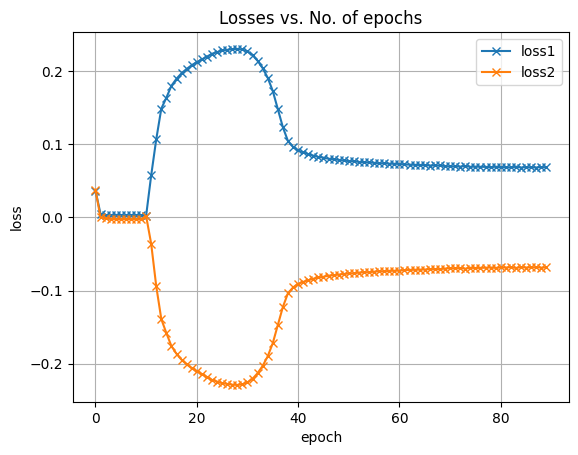

In [17]:
# Descongelar encoder
for param in model_transfer.encoder.parameters():
    param.requires_grad = True

N_EPOCHS_P2 = 150
history_phase2 = training(
    N_EPOCHS_P2, model_transfer, train_loader, val_loader,
    opt_func=lambda p: torch.optim.Adam(p, lr=1e-4)
)

# Gráfica combinada de ambas fases
plot_history(history_phase1 + history_phase2)


## Sección 6 — Guardar Modelo

In [18]:
torch.save({
    'encoder':  model_transfer.encoder.state_dict(),
    'decoder1': model_transfer.decoder1.state_dict(),
    'decoder2': model_transfer.decoder2.state_dict()
}, 'model_siata_transfer.pth')
print('Modelo guardado en model_siata_transfer.pth')

Modelo guardado en model_siata_transfer.pth


## Sección 7 — Evaluación

In [19]:
# Calcular scores de anomalía — alpha=0.1, beta=0.9 (énfasis adversarial AE2)
results = testing(model_transfer, test_loader, alpha=0.1, beta=0.9)
y_pred = np.concatenate([
    torch.stack(results[:-1]).flatten().detach().cpu().numpy(),
    results[-1].flatten().detach().cpu().numpy()
])
print(f'Scores calculados: {len(y_pred):,}')
print(f'Score range: [{y_pred.min():.6f}, {y_pred.max():.6f}]')


Scores calculados: 87,780
Score range: [0.001205, 0.115866]


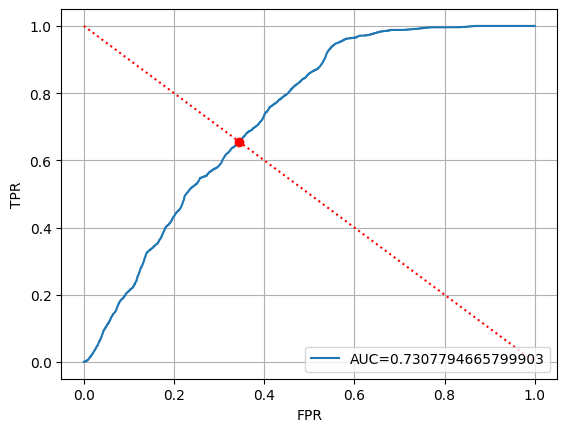

Threshold óptimo: 0.068941


In [20]:
# Curva ROC y threshold óptimo
raw_threshold = ROC(y_test, y_pred)

# ROC retorna array numpy; extraer escalar con fallback a mediana
arr = np.atleast_1d(raw_threshold)
threshold = float(arr[0]) if len(arr) > 0 else float(np.median(y_pred))
print(f'Threshold óptimo: {threshold:.6f}')


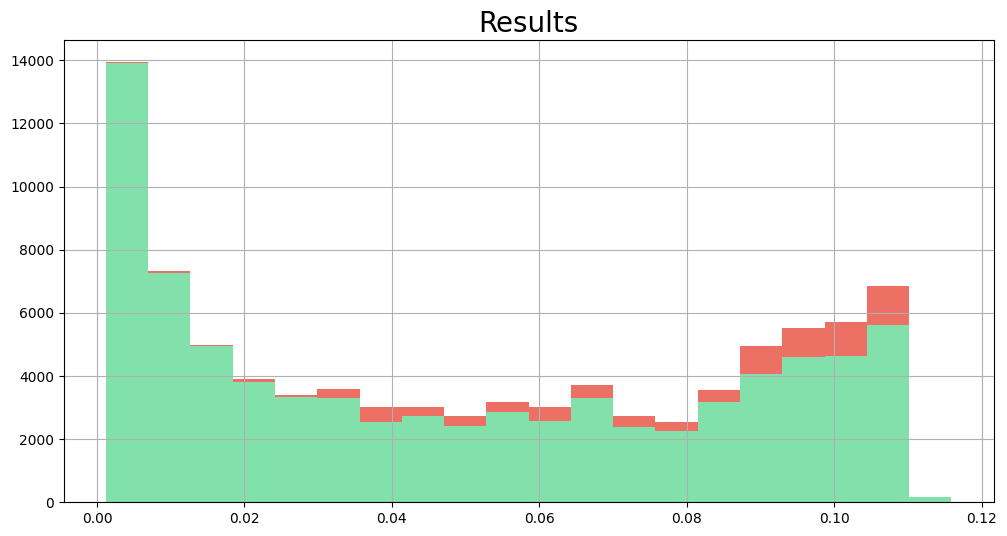

In [21]:
# Histograma de scores: normal vs anómalo
histogram(y_test, y_pred)

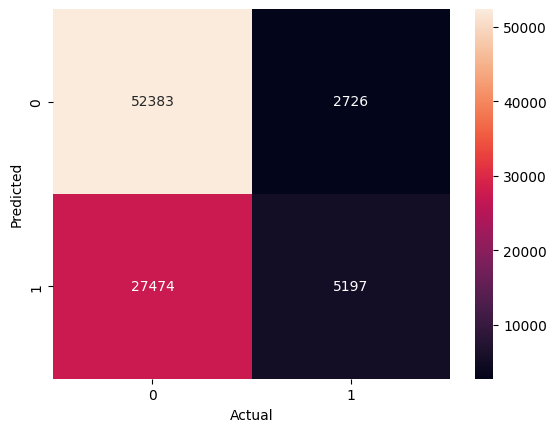


Threshold usado: 0.068941

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.95      0.66      0.78     79857
     Anómalo       0.16      0.66      0.26      7923

    accuracy                           0.66     87780
   macro avg       0.55      0.66      0.52     87780
weighted avg       0.88      0.66      0.73     87780



In [22]:
# Matriz de confusión al threshold óptimo
y_pred_binary = (y_pred >= threshold).astype(int)
confusion_matrix(y_test, y_pred_binary)
print(f'\nThreshold usado: {threshold:.6f}')
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_binary, target_names=['Normal', 'Anómalo']))


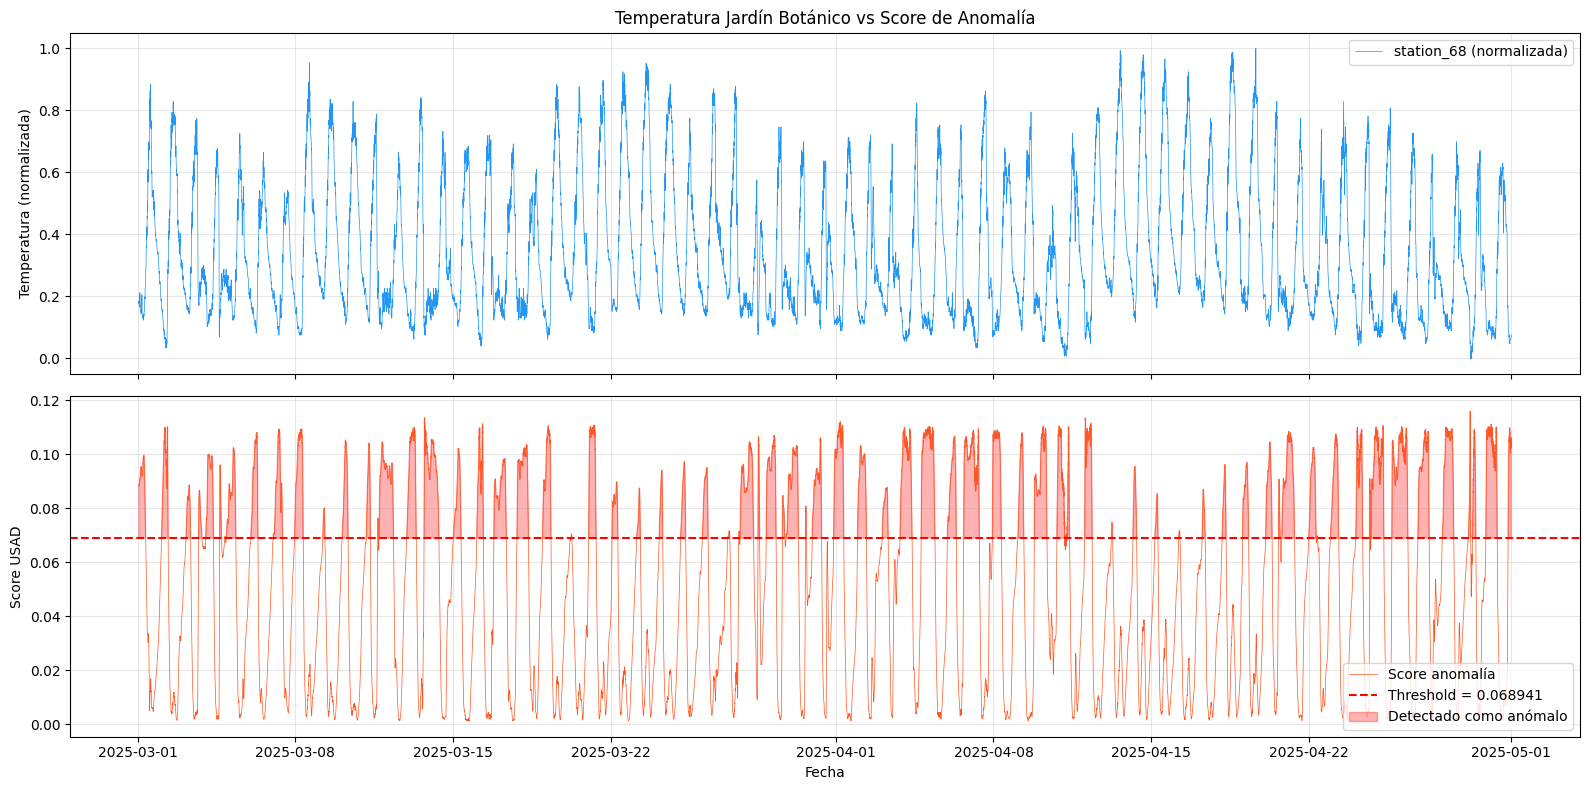

In [23]:
# Visualizar scores sobre la serie de tiempo de temperatura
timestamps = df_wide.index[window_size:]  # timestamps correspondientes a cada ventana
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Temperatura de una estación
ax1.plot(timestamps, df_scaled[window_size:, 0], linewidth=0.5, color='#2196F3', label='station_68 (normalizada)')
ax1.set_ylabel('Temperatura (normalizada)')
ax1.set_title('Temperatura Jardín Botánico vs Score de Anomalía')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Score de anomalía
ax2.plot(timestamps, y_pred, linewidth=0.5, color='#FF5722', label='Score anomalía')
ax2.axhline(y=threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold = {threshold:.6f}')
ax2.fill_between(timestamps, y_pred, threshold,
                 where=(y_pred >= threshold), alpha=0.3, color='red', label='Detectado como anómalo')
ax2.set_ylabel('Score USAD')
ax2.set_xlabel('Fecha')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Sección 8 — Ablación: Comparación con Baselines

Para la monografía: comparar el modelo con transfer learning contra dos baselines entrenados desde cero
con la misma arquitectura y datos.

In [24]:
# Baseline A: misma arquitectura que Transfer (w=240, z=z_size), Xavier aleatorio
# 90 épocas para igualar el total de Transfer (Phase1=10 + Phase2=80)
print(f'=== Baseline A: Xavier aleatorio, w_size={w_size}, z_size={z_size}, 90 épocas ===')
model_baseline_a = UsadModel(w_size, z_size)
model_baseline_a = to_device(model_baseline_a, device)
history_ba = training(90, model_baseline_a, train_loader, val_loader)


=== Baseline A: Xavier aleatorio, w_size=240, z_size=120, 90 épocas ===
Epoch [0], val_loss1: 0.0246, val_loss2: 0.0130
Epoch [1], val_loss1: 0.0242, val_loss2: -0.0124
Epoch [2], val_loss1: 0.0221, val_loss2: -0.0180
Epoch [3], val_loss1: 0.0753, val_loss2: -0.0659
Epoch [4], val_loss1: 0.0536, val_loss2: -0.0414
Epoch [5], val_loss1: 0.0436, val_loss2: -0.0388
Epoch [6], val_loss1: 0.0451, val_loss2: -0.0364
Epoch [7], val_loss1: 0.0442, val_loss2: -0.0403
Epoch [8], val_loss1: 0.0558, val_loss2: -0.0535
Epoch [9], val_loss1: 0.0508, val_loss2: -0.0477
Epoch [10], val_loss1: 0.0559, val_loss2: -0.0541
Epoch [11], val_loss1: 0.0520, val_loss2: -0.0498
Epoch [12], val_loss1: 0.0552, val_loss2: -0.0533
Epoch [13], val_loss1: 0.0578, val_loss2: -0.0559
Epoch [14], val_loss1: 0.0597, val_loss2: -0.0584
Epoch [15], val_loss1: 0.0562, val_loss2: -0.0545
Epoch [16], val_loss1: 0.0556, val_loss2: -0.0535
Epoch [17], val_loss1: 0.0564, val_loss2: -0.0552
Epoch [18], val_loss1: 0.0610, val_loss

In [25]:
# Baseline B: arquitectura reducida (z=100) para ablación de capacidad
print(f'=== Baseline B: Xavier aleatorio, w_size={w_size}, z_size=100, 90 épocas ===')
model_baseline_b = UsadModel(w_size, 100)
model_baseline_b = to_device(model_baseline_b, device)
history_bb = training(90, model_baseline_b, train_loader, val_loader)


=== Baseline B: Xavier aleatorio, w_size=240, z_size=100, 90 épocas ===
Epoch [0], val_loss1: 0.0360, val_loss2: 0.0058
Epoch [1], val_loss1: 0.0167, val_loss2: -0.0075
Epoch [2], val_loss1: 0.0372, val_loss2: -0.0253
Epoch [3], val_loss1: 0.0362, val_loss2: -0.0326
Epoch [4], val_loss1: 0.0319, val_loss2: -0.0254
Epoch [5], val_loss1: 0.0373, val_loss2: -0.0306
Epoch [6], val_loss1: 0.0366, val_loss2: -0.0331
Epoch [7], val_loss1: 0.0369, val_loss2: -0.0338
Epoch [8], val_loss1: 0.0671, val_loss2: -0.0651
Epoch [9], val_loss1: 0.0521, val_loss2: -0.0500
Epoch [10], val_loss1: 0.0647, val_loss2: -0.0620
Epoch [11], val_loss1: 0.0667, val_loss2: -0.0647
Epoch [12], val_loss1: 0.0606, val_loss2: -0.0589
Epoch [13], val_loss1: 0.0510, val_loss2: -0.0496
Epoch [14], val_loss1: 0.0529, val_loss2: -0.0517
Epoch [15], val_loss1: 0.0472, val_loss2: -0.0447
Epoch [16], val_loss1: 0.0483, val_loss2: -0.0464
Epoch [17], val_loss1: 0.0508, val_loss2: -0.0492
Epoch [18], val_loss1: 0.0545, val_loss

In [26]:
from sklearn.metrics import roc_auc_score

def get_scores(model, loader):
    # mismo alpha/beta que el modelo transfer para comparación justa
    results = testing(model, loader, alpha=0.1, beta=0.9)
    return np.concatenate([
        torch.stack(results[:-1]).flatten().detach().cpu().numpy(),
        results[-1].flatten().detach().cpu().numpy()
    ])

y_pred_ba = get_scores(model_baseline_a, test_loader)
y_pred_bb = get_scores(model_baseline_b, test_loader)

auc_transfer = roc_auc_score(y_test, y_pred)
auc_ba       = roc_auc_score(y_test, y_pred_ba)
auc_bb       = roc_auc_score(y_test, y_pred_bb)

print('=== Comparación AUC-ROC (alpha=0.1, beta=0.9) ===')
print(f'Transfer Learning (submatriz, z={z_size}, Phase1=10 + Phase2=150 épocas): AUC = {auc_transfer:.4f}')
print(f'Baseline A       (Xavier,     z={z_size}, 90 épocas):                    AUC = {auc_ba:.4f}')
print(f'Baseline B       (Xavier,     z=100,      90 épocas):                    AUC = {auc_bb:.4f}')


=== Comparación AUC-ROC ===
Transfer Learning (submatriz, z=120, Phase1=10 + Phase2=80 épocas): AUC = 0.7308
Baseline A       (Xavier,     z=120, 90 épocas):                   AUC = 0.7143
Baseline B       (Xavier,     z=100,      90 épocas):                   AUC = 0.6955


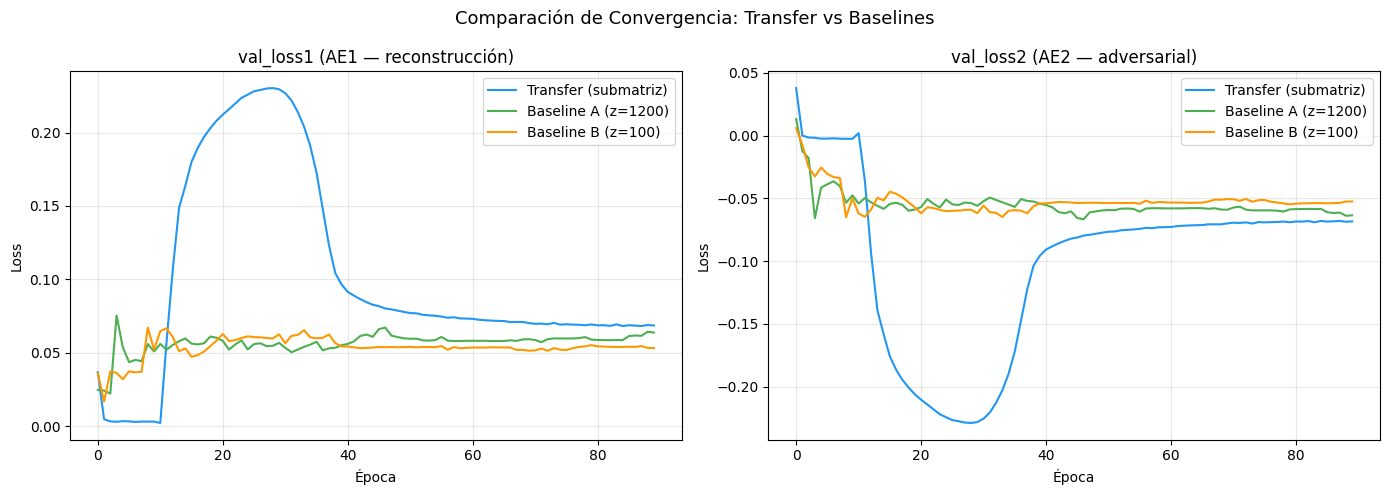

In [27]:
# Comparar curvas de convergencia
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

h_transfer = history_phase1 + history_phase2
for h, label, color in [
    (h_transfer, 'Transfer (submatriz)', '#2196F3'),
    (history_ba, f'Baseline A (z={z_size})', '#4CAF50'),
    (history_bb, 'Baseline B (z=100)',  '#FF9800')
]:
    losses1 = [x['val_loss1'] for x in h]
    losses2 = [x['val_loss2'] for x in h]
    ax1.plot(losses1, '-', label=label, color=color)
    ax2.plot(losses2, '-', label=label, color=color)

ax1.set_title('val_loss1 (AE1 — reconstrucción)')
ax1.set_xlabel('Época'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.set_title('val_loss2 (AE2 — adversarial)')
ax2.set_xlabel('Época'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Comparación de Convergencia: Transfer vs Baselines', fontsize=13)
plt.tight_layout()
plt.show()

## Sección 9 — Prueba Rápida (Sanity Check)

Verifica que el modelo guardado carga correctamente y produce scores esperados.

In [28]:
# Cargar modelo guardado y verificar reproducibilidad
checkpoint = torch.load('model_siata_transfer.pth', map_location=device)
model_loaded = UsadModel(w_size, z_size)
model_loaded = to_device(model_loaded, device)
model_loaded.encoder.load_state_dict(checkpoint['encoder'])
model_loaded.decoder1.load_state_dict(checkpoint['decoder1'])
model_loaded.decoder2.load_state_dict(checkpoint['decoder2'])

# Prueba con ventana anómala vs normal conocida
anomaly_indices = np.where(y_test == 1)[0]
normal_indices  = np.where(y_test == 0)[0]

if len(anomaly_indices) > 0:
    idx_a = anomaly_indices[0]
    idx_n = normal_indices[0]

    s_anomaly = to_device(torch.from_numpy(windows_test[idx_a:idx_a+1]).float(), device)
    s_normal  = to_device(torch.from_numpy(windows_test[idx_n:idx_n+1]).float(), device)

    with torch.no_grad():
        def score_single(model, x):
            w1 = model.decoder1(model.encoder(x))
            w2 = model.decoder2(model.encoder(w1))
            return (0.1 * torch.mean((x - w1)**2) + 0.9 * torch.mean((x - w2)**2)).item()

        sc_a = score_single(model_loaded, s_anomaly)
        sc_n = score_single(model_loaded, s_normal)

    print(f'Score ventana ANÓMALA:  {sc_a:.8f}')
    print(f'Score ventana NORMAL:   {sc_n:.8f}')
    print(f'Anomalía > Normal:      {sc_a > sc_n} ← debe ser True')
else:
    print('No hay ventanas anómalas en el test set (revisar labeling)')

Score ventana ANÓMALA:  0.08853027
Score ventana NORMAL:   0.08860168
Anomalía > Normal:      False ← debe ser True
